In [2]:
!pip install numpy
!pip install matplotlib
!pip install graphviz

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from graphviz import Digraph

In [6]:
def f(x):
    return 3*x**2-4*x+5

In [7]:
f(3.0)

20.0

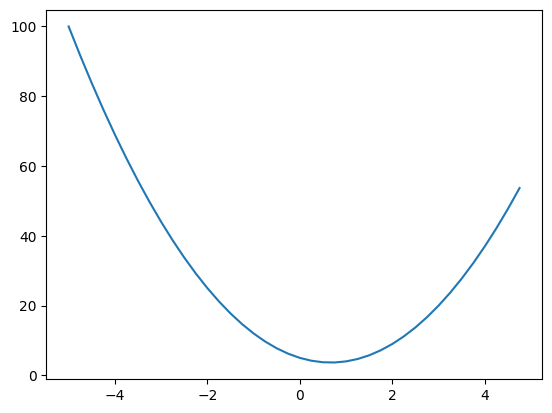

In [8]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [7]:
h=0.001
x=3.0
(f(x+h)-f(x))

0.01400300000000243

In [8]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [9]:
h=0.001
#inputs
a=2.0
b=-3.0
c=10.0
d1=a*b+c
a+=h
d2=a*b+c
print('d1',d1)
print('d2',d2)
print('slope',(d2-d1)/h)

d1 4.0
d2 3.997
slope -3.0000000000001137


In [4]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.grad=0.0
        self._backward=lambda :None
        self.label=label
        self._prev=set(_children)
        self._op=_op

    def __repr__(self):
        return f'value(data={self.data})'

    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        
        out=Value(self.data+other.data, (self,other),"+")

        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward
        return out
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),'*')
        
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    def __rmul__(self,other):
        return self*other

    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out=Value(self.data**other, (self,),f'**{other}')

        def _backward():
            self.grad=other * (self.data ** (other-1)) * out.grad
        out._backward=_backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward
        return out

    def __sub__(self,other):
        return self+(-other)
        
    def __truediv__(self,other):
        return self * other**-1
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad=out.data*out.grad
        out._backward=_backward
        return out 

    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()


In [11]:
a=Value(2.0)
b=Value(3.0)


value(data=0.6666666666666666)

In [ ]:
a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
e=a*b; e.label='e'
d=e+c;d.label='d'
f=Value(-2.0,label='f')
L=f*d; L.label='L'

In [5]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

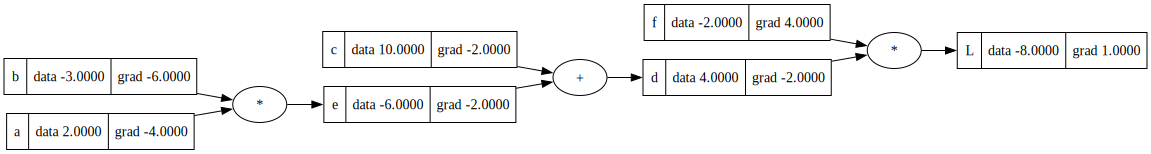

In [43]:
draw_dot(L)

In [11]:
L.grad=1.0
d.grad=-2.0
f.grad=4.0
e.grad=-2.0
c.grad=-2.0
a.grad= -2.0*2.0
b.grad= -2.0*3.0

In [45]:
def lol():
    h=0.001
    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e.label='e'
    d=e+c;d.label='d'
    f=Value(-2.0,label='f')
    L=f*d; L.label='L'
    L1=L.data
    
    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    b.data+=h
    c=Value(10.0,label='c')
    e=a*b; e.label='e'
    
    d=e+c;d.label='d'
    f=Value(-2.0,label='f')
    L=f*d; L.label='L'
    L2=L.data

    print((L2-L1)/h)

lol()

-3.9999999999995595


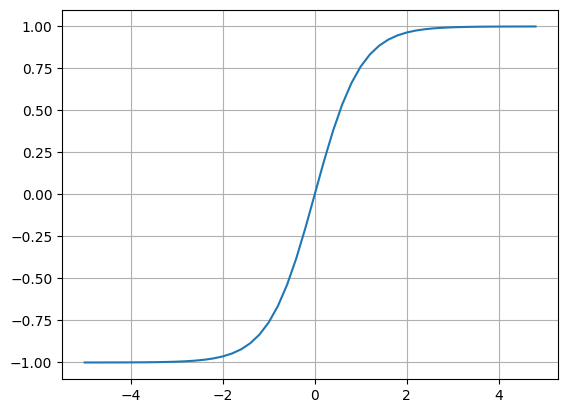

In [53]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [13]:
X1=Value(2.0,label='x1')
X2=Value(0.0,label='x2')

W1=Value(-3.0,label="w1")
W2=Value(1.0,label="w2")

b=Value(6.884534343356768,label='b')
X1W1=X1*W1;X1W1.label='x1w1'
X2W2=X2*W2;X2W2.label='x2w2'
X1W1X2W2=X1W1 + X2W2; X1W1X2W2.label='x1w1 + x2w2'
n=X1W1X2W2 +b;n.label='n'
o=n.tanh();o.label='o'
o.backward()

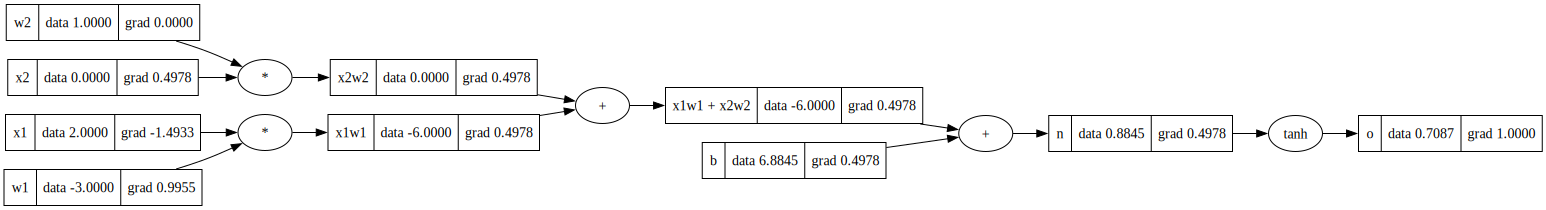

In [16]:
draw_dot(o)

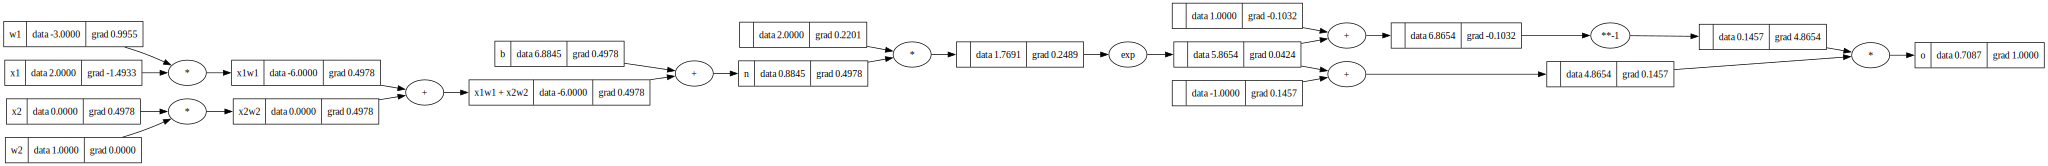

In [19]:
X1=Value(2.0,label='x1')
X2=Value(0.0,label='x2')

W1=Value(-3.0,label="w1")
W2=Value(1.0,label="w2")

b=Value(6.884534343356768,label='b')
X1W1=X1*W1;X1W1.label='x1w1'
X2W2=X2*W2;X2W2.label='x2w2'
X1W1X2W2=X1W1 + X2W2; X1W1X2W2.label='x1w1 + x2w2'
n=X1W1X2W2 +b;n.label='n'
e=(2*n).exp()
o=(e-1)/(e+1)
o.label='o'
o.backward()
draw_dot(o)

In [29]:
!pip install torch
import torch 

x1=torch.Tensor([2.0]).double(); x1.requires_grad=True
x2=torch.Tensor([0.0]).double(); x2.requires_grad=True
w1=torch.Tensor([-3.0]).double(); w1.requires_grad=True
w2=torch.Tensor([1.0]).double(); w2.requires_grad=True
b=torch.Tensor([6.8890349854]).double(); b.requires_grad=True
n=x1*w1 +x2*w2 +b
o=torch.tanh(n)
print(o.data.item())
o.backward()

print('----')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7109166481419549
----
x2 0.49459751939460794
w2 0.0
x1 -1.4837925581838238
w1 0.9891950387892159


In [31]:
o.shape

torch.Size([1])

In [75]:
import random
class Neuron:
    def __init__(self,nin):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    def parameters(self):
        return self.w+[self.b]
        
    def __call__(self,x):
        # w*x+b
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        out=act.tanh()
        return out

class Layer:
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs=[n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        


In [216]:
x=[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)

value(data=-0.2524110170679541)

In [77]:
len(n.parameters())
print(n.parameters())

[value(data=-0.11826002855947038), value(data=-0.4346003383164332), value(data=-0.20067749023039916), value(data=-0.8784747612591031), value(data=0.25124479552767043), value(data=-0.04994223622929206), value(data=0.3554443104738194), value(data=-0.8711586527137558), value(data=0.6106936150233995), value(data=0.06546202489992492), value(data=-0.33913538410236255), value(data=-0.03607018861813249), value(data=0.4065370785512914), value(data=0.3043935126813524), value(data=-0.016543663597745395), value(data=-0.32906314132000825), value(data=-0.4289102181327171), value(data=-0.9673431092216709), value(data=0.8242993291429004), value(data=-0.18608415740637407), value(data=0.0031167477012510325), value(data=-0.11576596723445509), value(data=0.011993398078721906), value(data=-0.8190375538700221), value(data=-0.8700639972789741), value(data=0.28669018467507046), value(data=0.14881439881956626), value(data=0.6598894744089883), value(data=-0.1357290072442594), value(data=0.5265225193826679), val

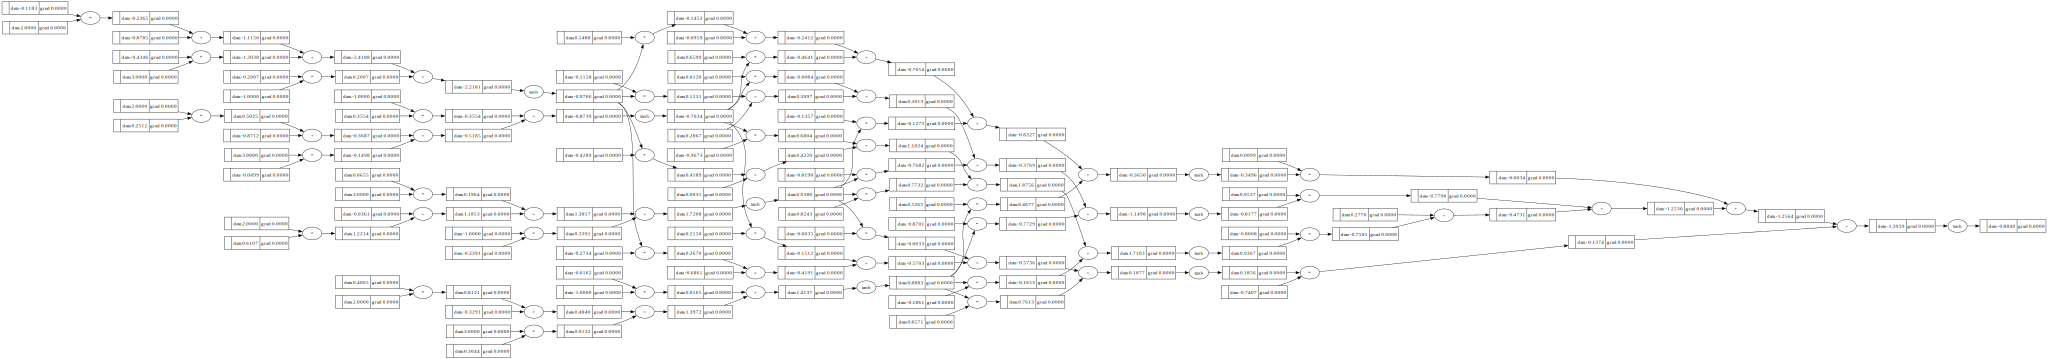

In [78]:
draw_dot(n(x))

In [217]:
xs=[[2.0,3.0,-1.0],
    [3.0,-1,0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]]
ys=[1.0,-1.0,-1.0,1.0]


In [218]:
for k in range(20):
    #forward pass
    ypred=[n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))

    for p in n.parameters():
        p.grad=0.0
    #backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data+=-0.05*p.grad

    print(k,loss.data)
ypred

0 4.7776436929512185
1 0.8314459991838205
2 0.39474379744777616
3 0.23716346203103728
4 0.17312016607178607
5 0.1369915394297718
6 0.11299655172375074
7 0.09589020074600266
8 0.08309434712961147
9 0.07317623704907468
10 0.06527394855344025
11 0.05883752808541258
12 0.05349955936018519
13 0.04900530184605101
14 0.045172646289528814
15 0.041868012473726804
16 0.038991241374743
17 0.03646579439136878
18 0.034232205294309696
19 0.03224359203693992


[value(data=0.9305871195278297),
 value(data=-0.8834212714340732),
 value(data=-0.9109932796237251),
 value(data=0.9231062562017709)]

In [206]:

loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
loss

value(data=0.09448604773317931)

In [207]:
#rerun to check loss
ypred=[n(x) for x in xs]
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
loss

value(data=0.05922525967641788)

In [208]:
loss.backward()
n.layers[0].neurons[0].w[0].grad


1.8272197364863114

In [209]:
n.layers[0].neurons[0].w[0].data

-0.3763484003849529

In [210]:
for p in n.parameters():
    p.data+=-0.01*p.grad

In [211]:
n.layers[0].neurons[0].w[0].data

-0.394620597749816

In [212]:
ypred

[value(data=0.8289524979260061),
 value(data=-0.9983712727309878),
 value(data=-0.9977918330219457),
 value(data=0.8269090327118566)]

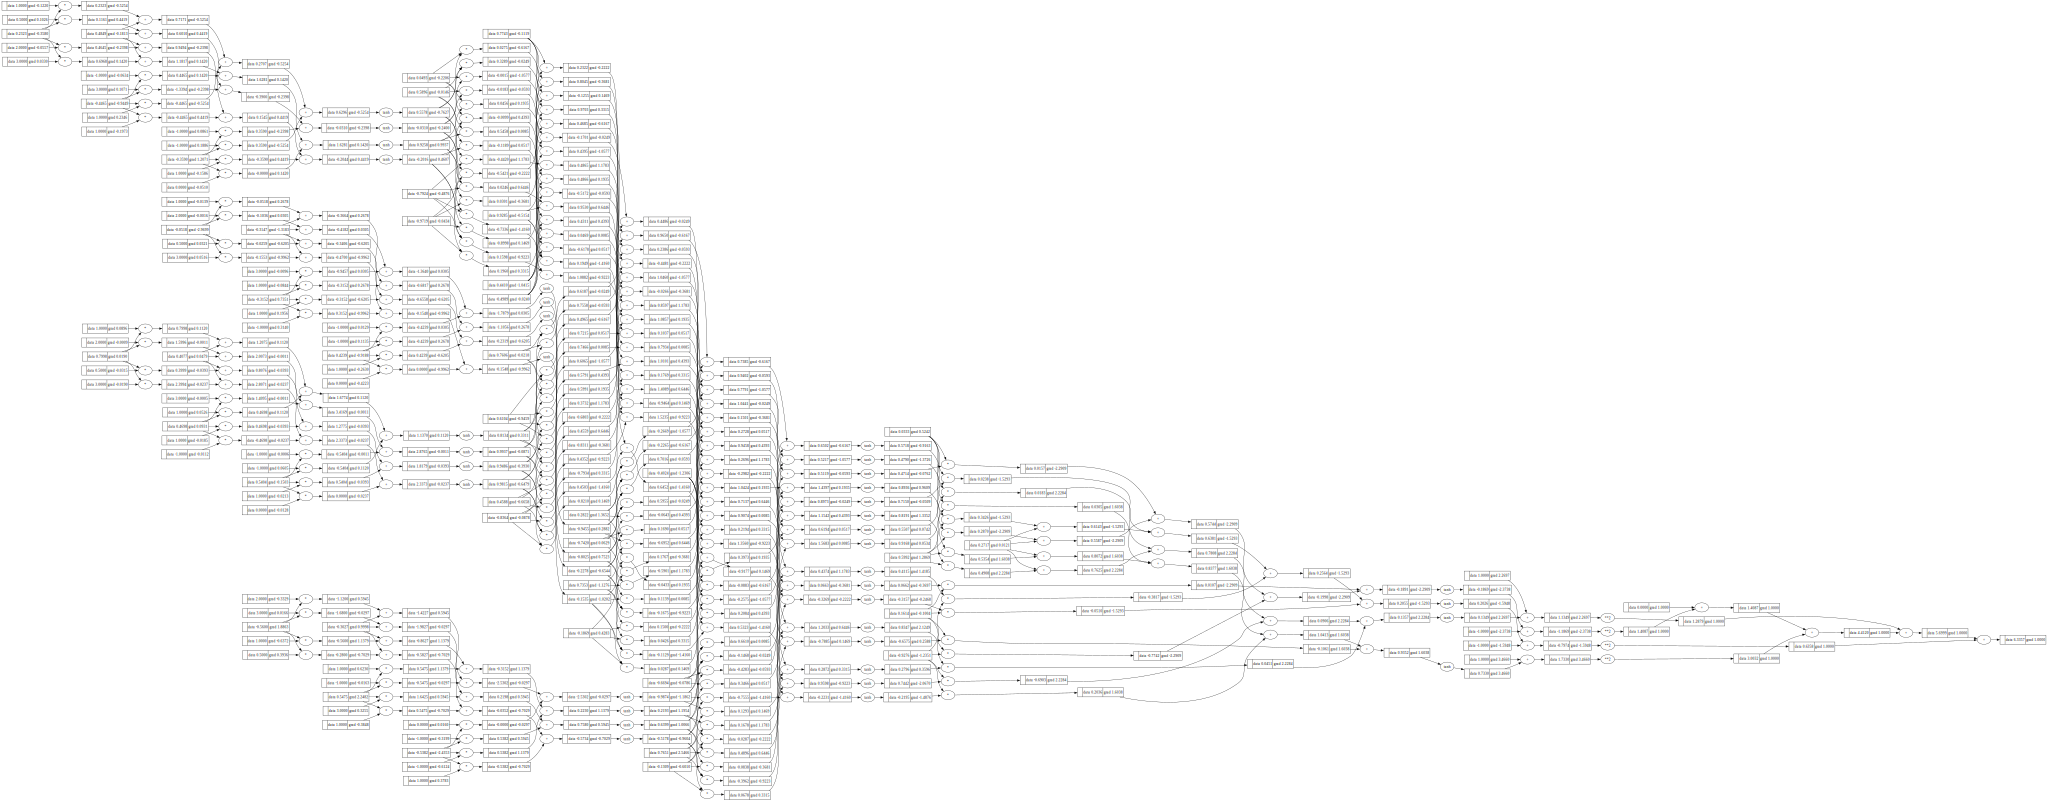

In [126]:

draw_dot(loss)